## Proposition Indexing
In a traditional RAG pipeline, you split a document and embed the raw splits directly. Proposition indexing changes this by taking the raw document splits and using an LLM to generate a "proposition" (a distilled, crisper summary of that segment). This optimized, highly descriptive summary is what gets embedded and searched.

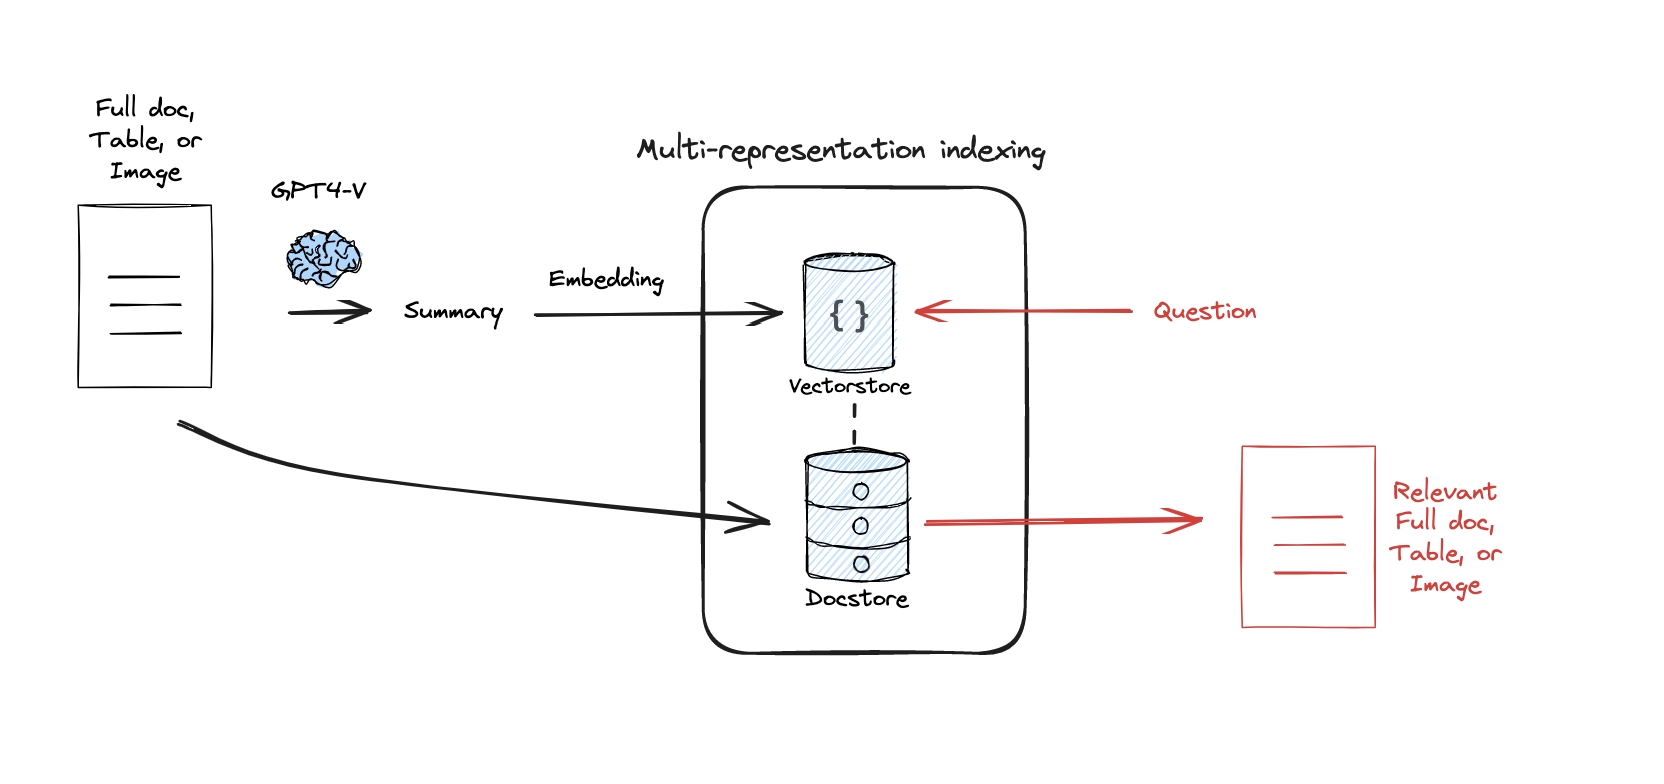

In [ ]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGSMITH_PROJECT"]="RAG-Routing"

In [ ]:
# Requires: pip install trafilatura langchain-community

import trafilatura
from langchain_core.documents import Document

rag_prod_grade = "https://developers.llamaindex.ai/python/framework/optimizing/production_rag/"
agentic_ai_prod = "https://mitsloan.mit.edu/ideas-made-to-matter/agentic-ai-explained"

urls = [
    rag_prod_grade,
    agentic_ai_prod
]

documents = []
for url in urls:
    downloaded = trafilatura.fetch_url(url)
    # Extracts main text and converts to markdown while stripping site chrome
    clean_text = trafilatura.extract(
        downloaded, 
        output_format="markdown", 
        include_links=False
    )
    if clean_text:
        documents.append(Document(page_content=clean_text, metadata={"source": url}))

# Each doc now contains only the main article content
documents

In [ ]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_ollama import ChatOllama

llm = ChatOllama(model="gemma3:4b")

prompt = ChatPromptTemplate.from_template(
    """
    Summarize the following document:\n\n{doc}
"""
)

sum_chain = {"doc" : lambda x : x.page_content} | prompt | llm | StrOutputParser()

summarized_docs = sum_chain.batch(
    documents, {"max_concurrency": 5}
)

summarized_docs

In [ ]:
from langchain_core.callbacks import CallbackManagerForRetrieverRun
from langchain_core.retrievers import BaseRetriever
from langchain_core.documents import Document
from typing import List, Any

class MultiVectorRetriever(BaseRetriever):
    vectorstore: Any
    docstore: Any
    id_key: Any
    
    def _get_relevant_documents(
        self, query: str, *, run_manager: CallbackManagerForRetrieverRun
    ) -> List[Document]:
        sub_docs = self.vectorstore.similarity_search(query)
        
        # 1. Deduplicate IDs to prevent fetching the same parent doc multiple times
        # 2. Filter out None values in case metadata is missing
        parent_ids = list(dict.fromkeys(
            doc.metadata.get(self.id_key) 
            for doc in sub_docs 
            if doc.metadata.get(self.id_key)
        ))
        
        # 3. Filter out missing entries returned from docstore
        parent_docs = self.docstore.mget(parent_ids)
        return [doc for doc in parent_docs if doc is not None]

In [ ]:
from langchain_chroma import Chroma
from langchain_ollama import OllamaEmbeddings

emd_fn = OllamaEmbeddings(model='nomic-embed-text:latest')

vector_store = Chroma(
    embedding_function=emd_fn,
    collection_name="rag-n-agentic",
    persist_directory='/path'
)

In [ ]:
import uuid
from langchain_core.stores import LocalFileStore

store  = LocalFileStore("local_docstore")
id_key = "doc_id"

mvr = MultiVectorRetriever(
    docstore=store,
    vectorstore=vector_store,
    id_key=id_key
)

doc_ids = [str(uuid.uuid4()) for _ in documents]

summary_docs = [
    Document(page_content=s, metadata={id_key: doc_ids[i]})
    for i, s in enumerate(summarized_docs)
]

mvr.vectorstore.add_documents(summary_docs)
mvr.docstore.mset(list(zip(doc_ids, documents)))

In [ ]:
question = "What is the fundamental difference between a traditional generative AI chatbot and an AI agent? Give an example where the agent must perceive, reason, use tools, and take action."
query_vs = vector_store.similarity_search(question)
query_vs

In [ ]:
query_ds = mvr.invoke(question)
query_ds

In [ ]:
from langchain_ollama import ChatOllama
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough

llm = ChatOllama(model="gemma3:4b")

prompt = ChatPromptTemplate.from_template("""
Answer the question based only on the following context:

{context}

Question: {question}
""")

def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)

# mvr = MultiVectorRetriever()

chain = {
    "context": mvr | format_docs,
    "question": RunnablePassthrough()
} | prompt | llm | StrOutputParser()


In [ ]:
rag_questions = [
    "What is the fundamental difference between a traditional generative AI chatbot and an AI agent?",
    "Why does agentic AI introduce greater security and governance risks than a normal chatbot?",
    "Why can data engineering, governance, stakeholder alignment, and workflow integration become the majority of the work when implementing agentic AI?",
    "Why is human oversight particularly important for AI agents when handling exceptions?",
    "How can an organization determine whether an AI agent is actually creating business value?",
]

agent_questions = [
    "Why might the optimal chunk for retrieval be different from the chunk needed by the LLM for answer generation?",
    "Why might basic top-k vector similarity retrieval become unreliable as the number of documents grows, and how can metadata filtering or document hierarchies help?",
    "Why shouldn't every user query use the same retrieval strategy?",
    "Why can embedding a sentence while linking it to its surrounding context be better than embedding a large chunk directly?",
    "Why might a pretrained embedding model perform poorly on a company's specific knowledge base, and how could embedding fine-tuning improve retrieval?"
]

In [ ]:
res1 = chain.batch(rag_questions)
res1 

In [ ]:
res2 = chain.batch(agent_questions)
res2 